# Эксперимент: ARIMA для предсказания временного ряда

Источник данных: `mean_monthly_air_temperature_stationary.csv`  

Задачи:
- загрузить и визуализировать ряд;
- подобрать оптимальные параметры ARIMA (p, d, q) по AIC;
- построить прогноз на отложенной выборке;
- построить график остатков предсказания;
- *(доп.)* сравнить с классическими ML-моделями на лагах.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
DATA_PATH = r"..\data\processed\mean_monthly_air_temperature_stationary.csv"

df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").set_index("date")

display(df.head())
print("shape:", df.shape)
print("period:", df.index.min().date(), "->", df.index.max().date())

,value
date,
1920-01-01,40.6
1920-02-01,40.8
1920-03-01,44.4
1920-04-01,46.7
1920-05-01,54.1


shape: (240, 1)
period: 1920-01-01 -> 1939-12-01


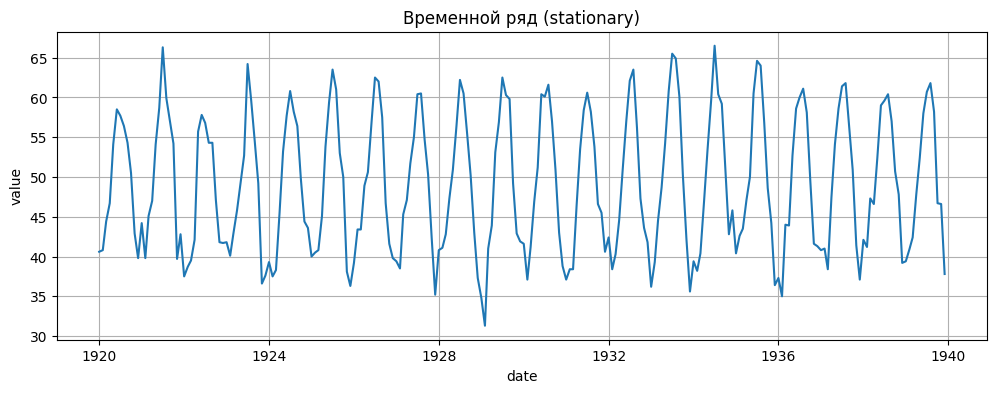

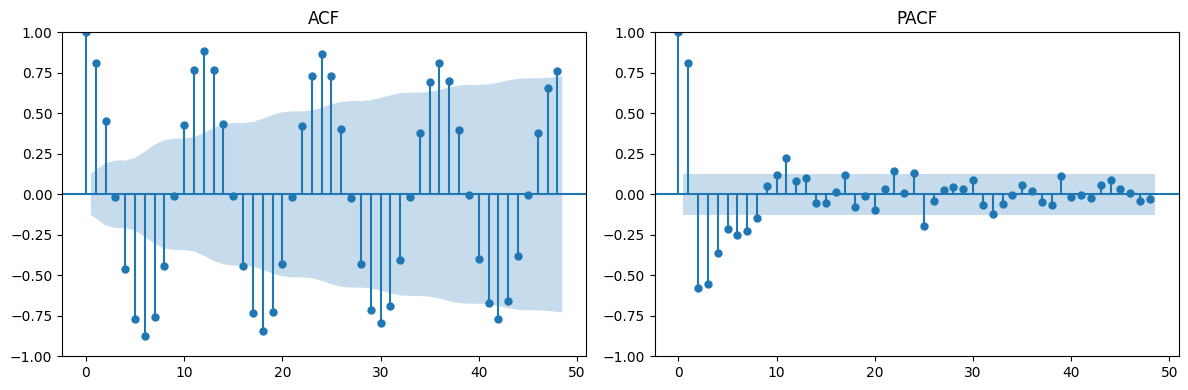

In [3]:
# Визуализация ряда
y = df["value"].asfreq("MS")  # Monthly Start

plt.figure(figsize=(12,4))
plt.plot(y)
plt.title("Временной ряд (stationary)")
plt.xlabel("date")
plt.ylabel("value")
plt.grid(True)
plt.show()

# ACF / PACF - для первичной диагностики p и q
fig, ax = plt.subplots(1,2, figsize=(12,4))
plot_acf(y.dropna(), lags=48, ax=ax[0])
plot_pacf(y.dropna(), lags=48, ax=ax[1], method="ywm")
ax[0].set_title("ACF")
ax[1].set_title("PACF")
plt.tight_layout()
plt.show()

Ряд выглядит стационарным по уровню (нет явного тренда/дрейфа среднего).
При этом сезонность очень сильная и стабильная: повторяющиеся пики/провалы примерно с периодом 12 месяцев.
Амплитуда колебаний примерно постоянная → дисперсия визуально не “разъезжается”.

На ACF заметны крупные значимые пики на лагах 12, 24, 36… — это классический признак годовой сезонности.

PACF показывает сильную связь на малых лагах (особенно лаг 1), дальше значения в основном ближе к нулю.

Вывод: структура ряда — это короткая память + выраженная сезонная компонента. Поэтому “обычная” ARIMA может работать, но логичнее (и часто точнее) пробовать SARIMA (с сезонными параметрами) именно из-за яркой сезонности.

train: 1920-01-01 -> 1937-12-01 | n = 216
test : 1938-01-01 -> 1939-12-01 | n = 24


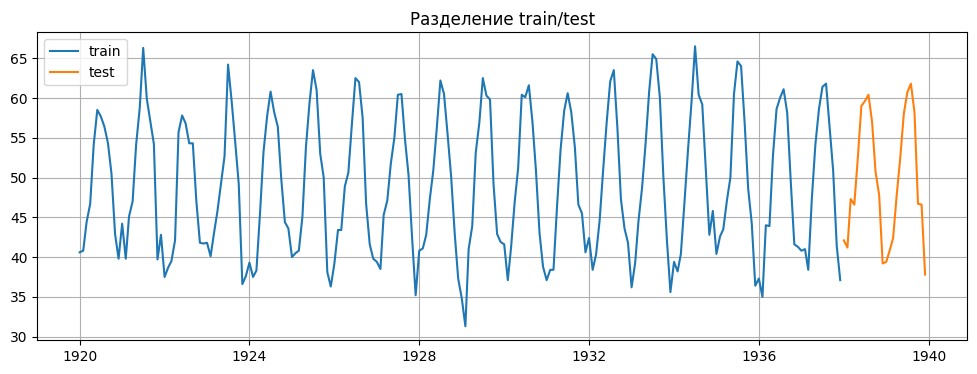

In [4]:
# Train / Test split
test_size = 24  # 24 месяца на тест

y_train = y.iloc[:-test_size]
y_test  = y.iloc[-test_size:]

print("train:", y_train.index.min().date(), "->", y_train.index.max().date(), "| n =", len(y_train))
print("test :", y_test.index.min().date(),  "->", y_test.index.max().date(),  "| n =", len(y_test))

plt.figure(figsize=(12,4))
plt.plot(y_train, label="train")
plt.plot(y_test, label="test")
plt.title("Разделение train/test")
plt.legend()
plt.grid(True)
plt.show()

Разделение корректное: тест — последние 24 месяца, при этом в тесте сохраняется та же сезонная форма.
Хорошо, что тест включает 2 сезона — это нормально проверяет модель именно на сезонном паттерне.

In [5]:
# Подбор параметров ARIMA(p, d, q) по AIC
# Ряд уже "stationary" , поэтому d  = 0.
# Для эксперимента всё равно проверим d=0..2.

p_values = range(0, 6)  # 0..5
d_values = range(0, 3)  # 0..2
q_values = range(0, 6)  # 0..5

best_aic = np.inf
best_order = None
best_model = None

results = []

for p in p_values:
    for d in d_values:
        for q in q_values:
            order = (p, d, q)
            try:
                model = ARIMA(
                    y_train, order=order,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )
                fitted = model.fit()
                aic = fitted.aic
                results.append((order, aic))
                if aic < best_aic:
                    best_aic = aic
                    best_order = order
                    best_model = fitted
            except Exception:
                continue

results_df = pd.DataFrame(results, columns=["order", "AIC"]).sort_values("AIC").reset_index(drop=True)
display(results_df.head(10))

print("Best order:", best_order, "| best AIC:", best_aic)

d:\Projects\Project_neto_time\.venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
d:\Projects\Project_neto_time\.venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
d:\Projects\Project_neto_time\.venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
d:\Projects\Project_neto_time\.venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
d:\Projects\Project_neto_time\.venv\lib\site-packages\st

,order,AIC
0,"(2, 0, 5)",995.297776
1,"(3, 1, 5)",997.550910
2,"(2, 0, 4)",998.378040
3,"(3, 0, 5)",998.588746
4,"(2, 1, 4)",999.589522
5,"(2, 1, 5)",999.624087
6,"(4, 0, 5)",1000.534683
7,"(5, 0, 5)",1001.880473
8,"(4, 1, 5)",1002.280425
9,"(3, 0, 4)",1003.470796


Best order: (2, 0, 5) | best AIC: 995.2977761439598


MAE  = 2.0716
RMSE = 2.7865


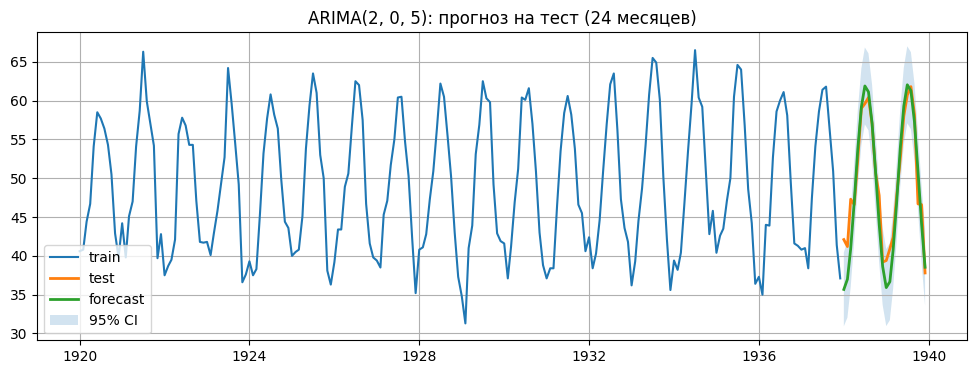

In [7]:
# Прогноз на тест
fitted = best_model  # уже обучена на train

forecast_res = fitted.get_forecast(steps=len(y_test))
y_pred = forecast_res.predicted_mean
conf_int = forecast_res.conf_int(alpha=0.05)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"MAE  = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")

plt.figure(figsize=(12,4))
plt.plot(y_train, label="train")
plt.plot(y_test, label="test", linewidth=2)
plt.plot(y_pred, label="forecast", linewidth=2)
plt.fill_between(conf_int.index, conf_int.iloc[:,0], conf_int.iloc[:,1], alpha=0.2, label="95% CI")
plt.title(f"ARIMA{best_order}: прогноз на тест ({len(y_test)} месяцев)")
plt.legend()
plt.grid(True)
plt.show()

Прогноз хорошо повторяет сезонную форму (пики и провалы в нужных местах).
На отдельных точках есть заметные промахи, но большинство фактических значений визуально попадает внутрь доверительного интервала.
Ошибки по метрикам умеренные (MAE ≈ 2.07, RMSE ≈ 2.79): для температурного ряда это похоже на “адекватно”, но не идеально.
Важная деталь: так как сезонность сильная, модель фактически “ловит” сезонный шаблон — это видно по совпадению формы.

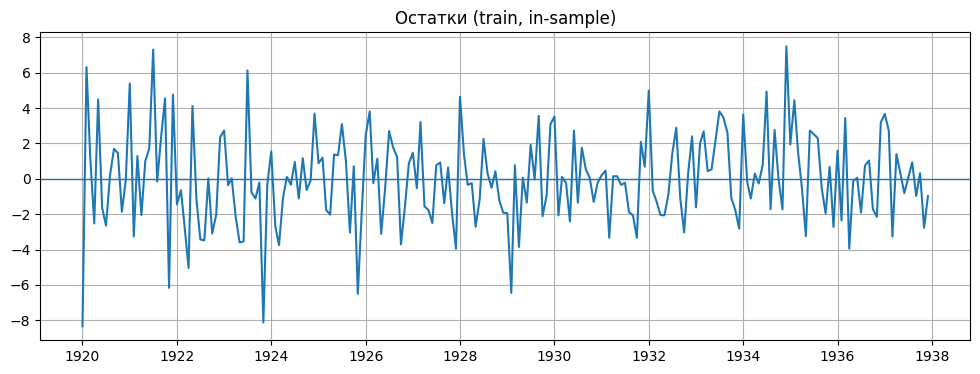

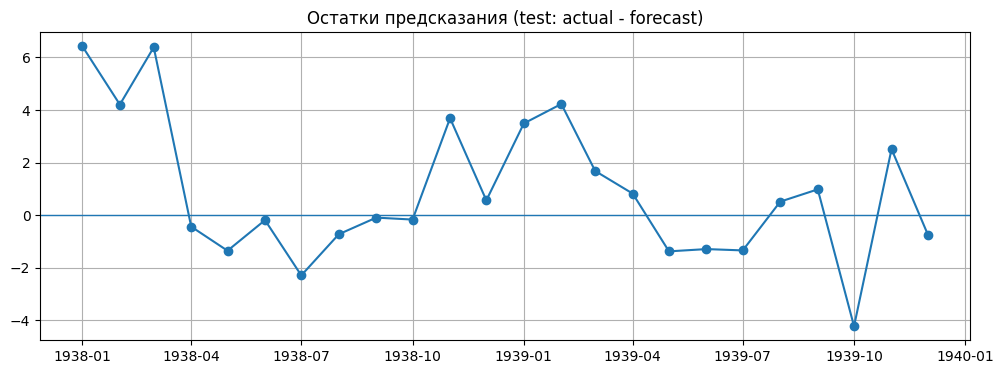

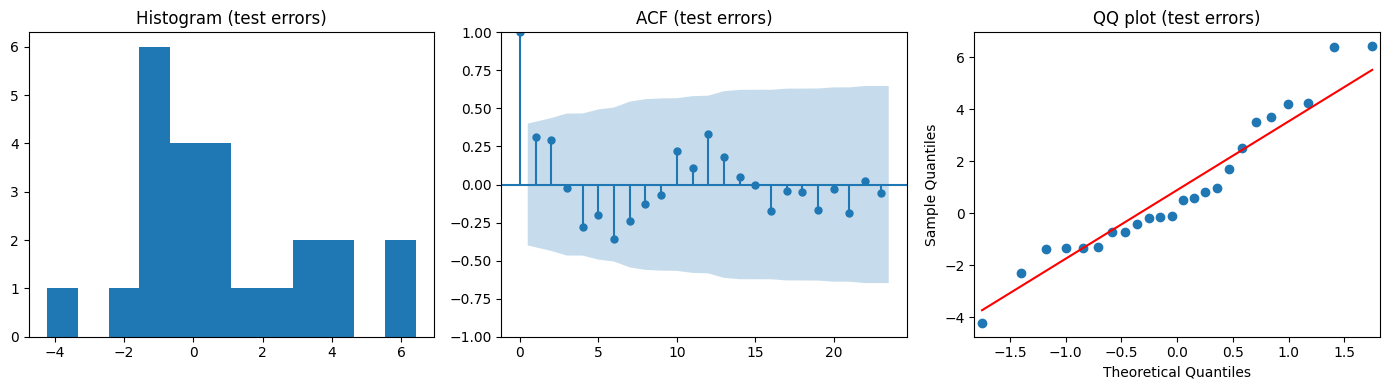

In [8]:
# Остатки предсказания
# 1) In-sample остатки на train
train_resid = fitted.resid

plt.figure(figsize=(12,4))
plt.plot(train_resid)
plt.axhline(0, linewidth=1)
plt.title("Остатки (train, in-sample)")
plt.grid(True)
plt.show()

# 2) Ошибки прогноза на test (actual - forecast)
test_errors = (y_test - y_pred)

plt.figure(figsize=(12,4))
plt.plot(test_errors, marker="o")
plt.axhline(0, linewidth=1)
plt.title("Остатки предсказания (test: actual - forecast)")
plt.grid(True)
plt.show()

# Диагностика: распределение + ACF + QQ
fig, ax = plt.subplots(1,3, figsize=(14,4))
ax[0].hist(test_errors.dropna(), bins=12)
ax[0].set_title("Histogram (test errors)")

plot_acf(test_errors.dropna(), lags=min(24, len(test_errors)-1), ax=ax[1])
ax[1].set_title("ACF (test errors)")

import statsmodels.api as sm
sm.qqplot(test_errors.dropna(), line="s", ax=ax[2])
ax[2].set_title("QQ plot (test errors)")

plt.tight_layout()
plt.show()

Остатки (train, in-sample)
Остатки колеблются вокруг нуля, явного систематического смещения не видно → по среднему модель в целом не “уезжает”.
Есть выбросы (резкие пики/провалы), то есть не всё объясняется ARIMA(2,0,5).
В некоторых участках видны “кучки” положительных/отрицательных значений → возможна слабая автокорреляция или недомодельная сезонная часть.

Остатки прогноза на тесте (actual − forecast)
Ошибка не выглядит чисто случайной: есть серии подряд положительных, потом серии отрицательных → это намёк на то, что часть структуры (чаще всего сезонной) модель не добрала.
Есть заметный отрицательный выброс ближе к концу теста (модель в тот момент переоценила значение).

## Дополнительное: классический ML на лагах

Идея: превратить ряд в задачу регрессии, где признаки — лаги (значения ряда за предыдущие месяцы) и/или календарные признаки.

Ниже — 2 базовые модели:
- `LinearRegression` (быстрый бейзлайн)
- `RandomForestRegressor` (нелинейности без сильной настройки)

Чтобы не подглядывать в будущее, используем **walk-forward** прогноз: на каждом шаге обучаем модель только на прошлом и предсказываем следующий момент времени.


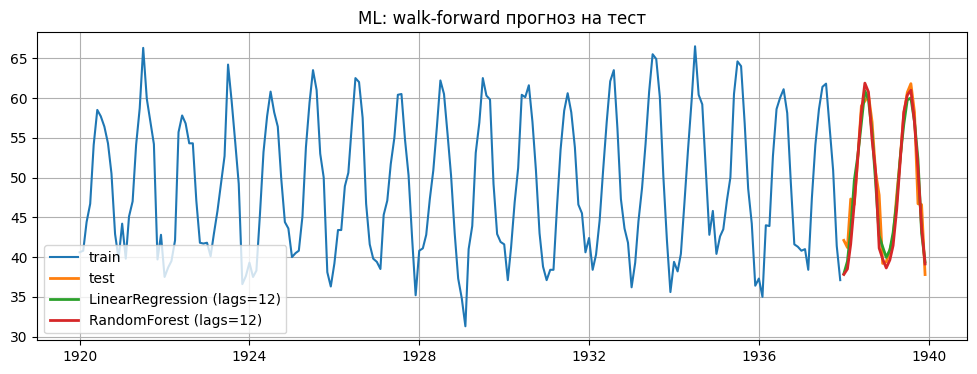

,model,MAE,RMSE
0,LinearRegression,1.889349,2.786517
1,RandomForest,1.765583,2.786517


In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

def make_lag_features(series: pd.Series, lags: int = 12) -> pd.DataFrame:
    X = pd.DataFrame(index=series.index)
    for lag in range(1, lags + 1):
        X[f"lag_{lag}"] = series.shift(lag)
    # календарный признак (месяц)
    X["month"] = series.index.month
    return X

def walk_forward_forecast(model, y: pd.Series, train_end_idx: int, lags: int = 12) -> pd.Series:
    '''
    Walk-forward:
    - на каждом шаге обучаемся на данных до t-1
    - предсказываем y_t
    '''
    y = y.copy()
    X_all = make_lag_features(y, lags=lags)
    preds = []
    idxs = []

    for i in range(train_end_idx, len(y)):
        X_train = X_all.iloc[:i].dropna()
        y_train_local = y.iloc[:i].loc[X_train.index]

        X_test = X_all.iloc[i:i+1]
        if X_test.isna().any(axis=1).iloc[0]:
            preds.append(np.nan)
            idxs.append(y.index[i])
            continue

        model.fit(X_train, y_train_local)
        preds.append(model.predict(X_test)[0])
        idxs.append(y.index[i])

    return pd.Series(preds, index=pd.Index(idxs, name="date"))

lags = 12
train_end_idx = len(y_train)

models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=400, random_state=42),
}

ml_results = []

plt.figure(figsize=(12,4))
plt.plot(y_train, label="train")
plt.plot(y_test, label="test", linewidth=2)

for name, model in models.items():
    pred = walk_forward_forecast(model, y, train_end_idx=train_end_idx, lags=lags)
    pred_test = pred.loc[y_test.index]

    mae = mean_absolute_error(y_test, pred_test)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    ml_results.append((name, mae, rmse))

    plt.plot(pred_test, label=f"{name} (lags={lags})", linewidth=2)

plt.title("ML: walk-forward прогноз на тест")
plt.legend()
plt.grid(True)
plt.show()

ml_results_df = pd.DataFrame(ml_results, columns=["model", "MAE", "RMSE"]).sort_values("RMSE")
display(ml_results_df)

Диагностика ошибок (hist / ACF / QQ)
Гистограмма: распределение не идеально нормальное, заметны хвосты/асимметрия из-за пары крупных ошибок.
ACF ошибок: большинство лагов внутри доверительной зоны, но на первых лагах видны небольшие значения → остатки почти белый шум, но не идеально.
QQ-plot: точки на концах отклоняются от линии → тяжёлые хвосты / выбросы, нормальность ошибок нарушена.

Общий итог

ARIMA(2,0,5) в целом справилась: сезонную форму на тесте воспроизводит, среднее смещение небольшое.
Но по остаткам видно, что модель не полностью “обеляет” ошибки (есть структура/серийность и выбросы).